# 03. Step-by-Step DAGs: The Map of Reality

We saw in **Notebook 02** that our data is full of hidden traps. Older people have more accidents, but they also drive slower (which is safer) and have worse vision (which is dangerous). 

If the Mayor bans elderly drivers based purely on the raw statistics, they might be making a huge mistake. To solve this, we cannot just throw data into a machine learning algorithm. We must explicitly map our assumptions about how the real world works using **DAGs (Directed Acyclic Graphs)**.

A DAG is a visual map of cause and effect. The arrows show what causes what. In this notebook, we will look at the **four core causal structures** that dictate whether a variable is our friend or our enemy when analyzing public policy.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid")
df = pd.read_csv('smart_city_road_safety_synthetic_5000.csv')
df['Accident_Numeric'] = df['Accident'].astype(int)

---
## 1. The Confounder (The Omitted Variable Trap)

A **Confounder** (represented as $C$) is a variable that causes **both** the Treatment ($T$) and the Outcome ($Y$). It sits above them like a puppet master, pulling the strings of both.

**Our Example:** `Vision_Quality`.
- As we age ($T$), our vision quality inherently degrades (Biology causes poor vision).
- Poor vision directly causes car accidents ($Y$).

If we omit the puppet master (Vision) from our mathematical models, the math will be tricked into blaming the Treatment (Age) for something the puppet master did. 

**The Causal Rule:** You MUST adjust for confounders. If you include the confounder in your regression model, you "block" the fake path, revealing the true effect of the Treatment.

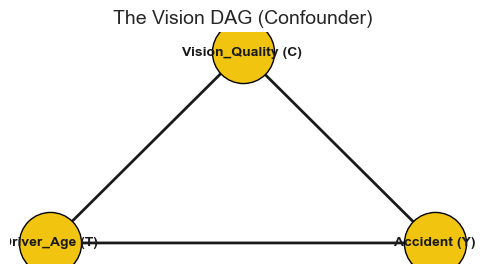

In [2]:
# 1. Define the arrows (From -> To)
edges_c = [("Vision_Quality (C)", "Accident (Y)"), 
           ("Driver_Age (T)", "Vision_Quality (C)"), 
           ("Driver_Age (T)", "Accident (Y)")]

# 2. Define the coordinates on the grid (X, Y) to place the nodes
pos_c = {"Vision_Quality (C)": (0, 1), "Driver_Age (T)": (-1, 0), "Accident (Y)": (1, 0)}

plt.figure(figsize=(6, 3))
G_c = nx.DiGraph()
G_c.add_edges_from(edges_c)

# 3. Draw the nodes, edges, and labels
nx.draw_networkx_nodes(G_c, pos_c, node_size=2000, node_color="#f1c40f", edgecolors="black")
nx.draw_networkx_edges(G_c, pos_c, arrows=True, width=2)
nx.draw_networkx_labels(G_c, pos_c, font_size=10, font_weight="bold")

plt.title("The Vision DAG (Confounder)", fontsize=14)
plt.axis("off")
plt.show()

Let's prove this visually. We will plot the Naive probability of an accident (Red curve). Then, we will run a regression that *adjusts* for `Vision_Quality` and plot the new curve (Green curve).

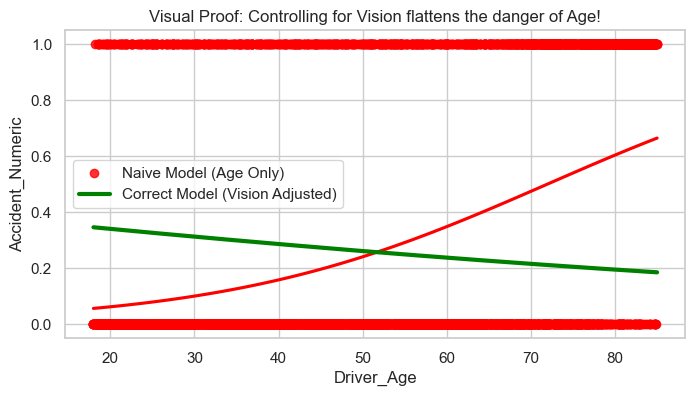

In [3]:
model_naive = smf.logit("Accident_Numeric ~ Driver_Age", data=df).fit(disp=False)
model_vision = smf.logit("Accident_Numeric ~ Driver_Age + Vision_Quality", data=df).fit(disp=False)

plt.figure(figsize=(8,4))
sns.regplot(data=df, x='Driver_Age', y='Accident_Numeric', logistic=True, ci=None, color='red', label='Naive Model (Age Only)')
df['Adjusted_Pred'] = model_vision.predict(df.assign(Vision_Quality=df['Vision_Quality'].mean()))
sns.lineplot(data=df, x='Driver_Age', y='Adjusted_Pred', color='green', linewidth=3, label='Correct Model (Vision Adjusted)')
plt.title("Visual Proof: Controlling for Vision flattens the danger of Age!")
plt.legend()
plt.show()

**The Verdict:** Look at the green line! Once we statistically control for `Vision_Quality` (holding vision constant across all ages), the effect of Age drops almost entirely flat. 

If the Mayor wants to save lives, banning the elderly is the wrong policy. The correct policy is **mandating vision exams for license renewal**.

---
## 2. The Mediator (The Compensatory Trap)

A **Mediator** ($M$) is the mechanism or chain reaction by which $T$ affects $Y$. It sits directly on the path between them ($T \rightarrow M \rightarrow Y$).

**Our Example:** `Driving_Speed`.
- As drivers age ($T$), they realize their reflexes are slower, so they voluntarily drive slower ($M$).
- Driving slower reduces the probability of a fatal crash ($Y$).

What happens if a data analyst decides to "control for speed" in their regression model? 

By controlling for speed, the analyst is forcing the math to compare a 20-year-old and an 80-year-old **driving at the exact same speed**. But in the real world, the 80-year-old *doesn't* drive at the same speed! By controlling the mediator, we are statistically deleting the elderly's best self-defense mechanism.

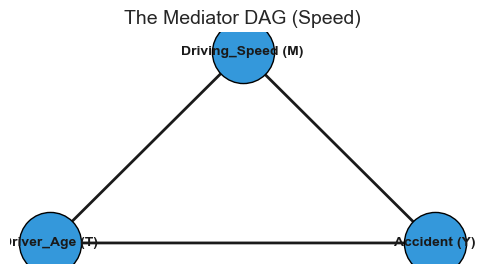

In [4]:
edges_m = [("Driver_Age (T)", "Driving_Speed (M)"), ("Driving_Speed (M)", "Accident (Y)"), ("Driver_Age (T)", "Accident (Y)")]
pos_m = {"Driver_Age (T)": (-1, 0), "Driving_Speed (M)": (0, 1), "Accident (Y)": (1, 0)}

plt.figure(figsize=(6, 3))
G_m = nx.DiGraph()
G_m.add_edges_from(edges_m)
nx.draw_networkx_nodes(G_m, pos_m, node_size=2000, node_color="#3498db", edgecolors="black")
nx.draw_networkx_edges(G_m, pos_m, arrows=True, width=2)
nx.draw_networkx_labels(G_m, pos_m, font_size=10, font_weight="bold")
plt.title("The Mediator DAG (Speed)", fontsize=14)
plt.axis("off")
plt.show()

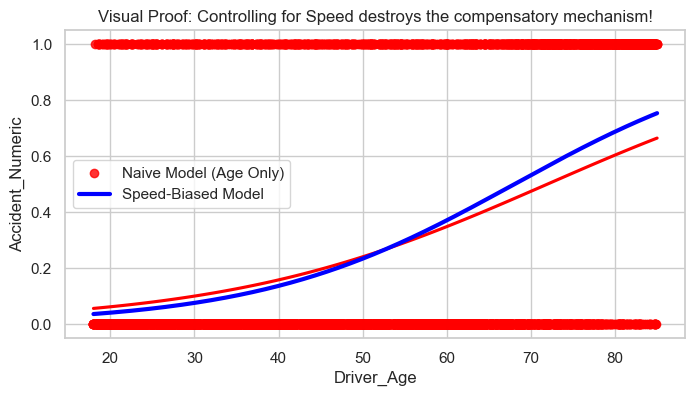

In [5]:
model_speed = smf.logit("Accident_Numeric ~ Driver_Age + Driving_Speed", data=df).fit(disp=False)

plt.figure(figsize=(8,4))
sns.regplot(data=df, x='Driver_Age', y='Accident_Numeric', logistic=True, ci=None, color='red', label='Naive Model (Age Only)')
df['Speed_Biased_Pred'] = model_speed.predict(df.assign(Driving_Speed=df['Driving_Speed'].mean()))
sns.lineplot(data=df, x='Driver_Age', y='Speed_Biased_Pred', color='blue', linewidth=3, label='Speed-Biased Model')
plt.title("Visual Proof: Controlling for Speed destroys the compensatory mechanism!")
plt.legend()
plt.show()

**The Verdict:** The blue line shoots violently into the sky! By controlling for `Driving_Speed`, the math makes the elderly look like absolute terrors on the road. 

**The Causal Rule:** NEVER control for a compensatory mediator if you want to know the total real-world effect of a policy. Including it creates **Over-control Bias**.

---
## 3. The Collider (Berkson's Paradox)

A **Collider** ($K$) is a variable that is caused by BOTH the Treatment ($T$) and the Outcome ($Y$). The arrows "collide" into it. ($T \rightarrow K \leftarrow Y$).

**Our Example:** `Severe_Hospitalization`.
- Older bodies are physically more fragile. (Age $\rightarrow$ Hospital). 
- Severe car crashes cause injuries. (Accident $\rightarrow$ Hospital).

Imagine the Mayor doesn't have access to the city's street cameras, so they only pull data from the City Hospital's ER. By only analyzing people who *already* ended up in the hospital, the Mayor is mathematically **Conditioning on a Collider**.

This creates a famous phenomenon called **Berkson's Paradox** (Selection Bias). Among people in the ER, if you see a 20-year-old, they are probably there because they were in a horrific, high-speed crash. But if you see an 85-year-old, they might be there just from a minor fender bender because their bones are fragile. By restricting the data to the hospital, you artificially make the young people look like the worst drivers!

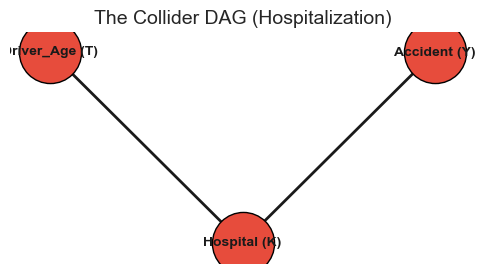

In [6]:
edges_k = [("Driver_Age (T)", "Hospital (K)"), ("Accident (Y)", "Hospital (K)")]
pos_k = {"Driver_Age (T)": (-1, 1), "Accident (Y)": (1, 1), "Hospital (K)": (0, 0)}

plt.figure(figsize=(6, 3))
G_k = nx.DiGraph()
G_k.add_edges_from(edges_k)
nx.draw_networkx_nodes(G_k, pos_k, node_size=2000, node_color="#e74c3c", edgecolors="black")
nx.draw_networkx_edges(G_k, pos_k, arrows=True, width=2)
nx.draw_networkx_labels(G_k, pos_k, font_size=10, font_weight="bold")
plt.title("The Collider DAG (Hospitalization)", fontsize=14)
plt.axis("off")
plt.show()

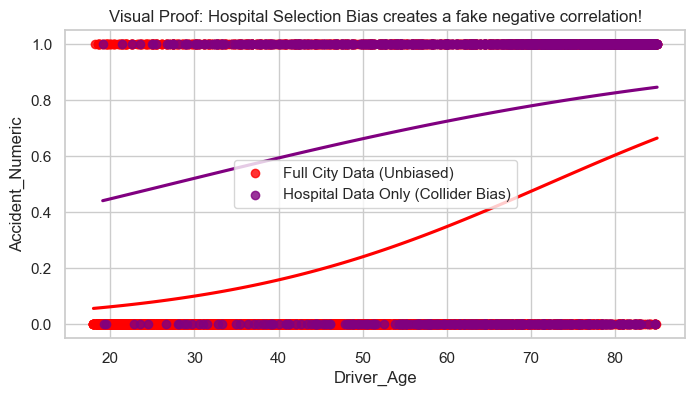

In [7]:
df_hospital = df[df['Severe_Hospitalization'] == 1]
model_collider = smf.logit("Accident_Numeric ~ Driver_Age", data=df_hospital).fit(disp=False)

plt.figure(figsize=(8,4))
sns.regplot(data=df, x='Driver_Age', y='Accident_Numeric', logistic=True, ci=None, color='red', label='Full City Data (Unbiased)')
sns.regplot(data=df_hospital, x='Driver_Age', y='Accident_Numeric', logistic=True, ci=None, color='purple', label='Hospital Data Only (Collider Bias)')
plt.title("Visual Proof: Hospital Selection Bias creates a fake negative correlation!")
plt.legend()
plt.show()

**The Verdict:** The purple line goes DOWN! If you only look at hospital records, you would conclude that being elderly magically *prevents* accidents.

**The Causal Rule:** Conditioning on a collider ruins your dataset. You cannot trust statistics if the sample was filtered based on the outcome of the variables you are trying to study.

---
## 4. The Precision Variable (The Good Helper)
Finally, what about a variable that causes the **Outcome**, but has absolutely nothing to do with the **Treatment**?

**Our Example:** `Weather`.
- Bad weather (Rain/Snow) obviously causes car accidents.
- But your Age does not control whether it rains today! Weather is entirely independent of Age.

Because it doesn't touch the Treatment, Weather is NOT a confounder. Leaving it out won't bias your results. However, putting it in your model absorbs a lot of the "random noise" in the outcome.

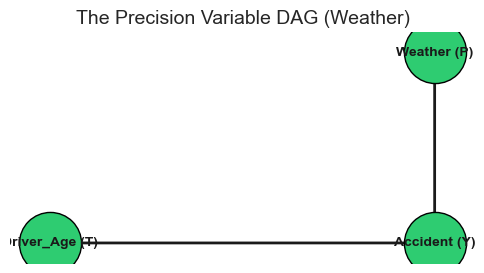

In [8]:
edges_p = [("Weather (P)", "Accident (Y)"), ("Driver_Age (T)", "Accident (Y)")]
pos_p = {"Driver_Age (T)": (-1, 0), "Weather (P)": (1, 1), "Accident (Y)": (1, 0)}

plt.figure(figsize=(6, 3))
G_p = nx.DiGraph()
G_p.add_edges_from(edges_p)
nx.draw_networkx_nodes(G_p, pos_p, node_size=2000, node_color="#2ecc71", edgecolors="black")
nx.draw_networkx_edges(G_p, pos_p, arrows=True, width=2)
nx.draw_networkx_labels(G_p, pos_p, font_size=10, font_weight="bold")
plt.title("The Precision Variable DAG (Weather)", fontsize=14)
plt.axis("off")
plt.show()

In [9]:
model_prec_base = smf.logit("Accident_Numeric ~ Driver_Age", data=df).fit(disp=False)
model_prec_good = smf.logit("Accident_Numeric ~ Driver_Age + C(Weather)", data=df).fit(disp=False)

print("Base Model Age Coef:", model_prec_base.params['Driver_Age'])
print("Precision Model Age Coef:", model_prec_good.params['Driver_Age'])

Base Model Age Coef: 0.05238293383861782
Precision Model Age Coef: 0.05356787182162737


**The Verdict:** The coefficient for Age stays roughly the same (no confounding bias!). 

**The Causal Rule:** A precision variable does not bias your results. In linear regressions (like predicting Money), adding a precision variable shrinks your error margins (a free lunch!). In logistic regressions (like predicting Accidents), it simply helps the model absorb the random noise without destroying the causal integrity of your policy variable. If you have them, include them!

---
## Summary
We now have a complete map of our reality. We know which variables to include (Vision, Weather) and which variables to avoid like the plague (Speed, Hospitalization). 

In **Notebook 04**, we will put all this knowledge to the test in a final showdown against a traditional Machine Learning model!